# VAE Anomaly Detector

Loss Fun: SSIM + KL Divergence

Variational: Encoder outputs a mean and a log variance. A vector is sampled from gaussian noise, and said vector is scaled and shifted by the mean and std from the encoder. This vector is the latent vector we pass our Decoder.


In [ ]:
# Download the dataset, setup packages
# SSIM download
!pip install torchmetrics
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
import random

# SSIM addition
from torchmetrics.image import StructuralSimilarityIndexMeasure

import torch as torch
import torch.nn as nn
import torch.optim as optim

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Already downloaded


In [ ]:
# Helper function to load in data set
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws', 'capsule']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [ ]:
# Written by AI
# Sets the weight initialization seed so it is the same every time
def set_seed(seed=77):
    """Locks down all random number generators for reproducibility."""
    # 1. Python built-in random module
    random.seed(seed)

    # 2. NumPy (This fixes your np.random.choice issue!)
    np.random.seed(seed)

    # 3. PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 4. CuDNN (GPU backend)
    # Note: Forcing deterministic behavior can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call this immediately!
set_seed(77)

In [ ]:
# What size to make latent vector dim?
class VAE_Encoder(nn.Module):
    def __init__(self, image_height, image_width, latent_vector_dim = 32):
        super().__init__()

        # Tighter bottleneck forces the model to compress harder
        # widens the reconstruction gap between normal and anomalous images.

        # CNN network
        self.convolution = nn.Sequential(

            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(256),
        )

        # Dummy pass to get flattened_size and spatial_size
        dummy_input = torch.zeros(1, 3, image_height, image_width)
        dummy_output = self.convolution(dummy_input)

        self.flattened_size = dummy_output.view(1, -1).size(1)
        self.spatial_shape = dummy_output.shape[1:]

        self.fully_connected_mu = nn.Linear(self.flattened_size, latent_vector_dim)
        self.fully_connected_log_var = nn.Linear(self.flattened_size, latent_vector_dim)

        # # fully connected layer
        # self.fully_connected_mu = nn.LazyLinear(latent_vector_dim)
        # # fully connected layer
        # self.fully_connnected_log_var = nn.LazyLinear(latent_vector_dim)

    def forward(self,x):

        # Go through our convolutional layers
        z = self.convolution(x)

        # flatten output into latent vector
        # if doing 1x1x1 convolution you do not flatten you jsut march on

        x = torch.flatten(z, start_dim =1)

        # now we want our flattened vector to pass through both fc layers to yeild 2 parameters which will act as our mean and variance
        mu = self.fully_connected_mu(x)
        log_var = self.fully_connected_log_var(x)

        return mu, log_var


In [ ]:
def reparametrization(mu, log_var):
      '''
      Here I want to create gaussian noise, select something random from there and do a shift and scale for mu and logvar
      '''
      # std = sqrt(variance)
      var = torch.exp(log_var)
      std = torch.sqrt(var)

      # torch.randn_like returns a tensor with same size as input of a random value from a gaussian distribution with mean 0 and std 1
      # inputting in std as want to have same shapw
      eps = torch.randn_like(std)

      # scale and shift are gaussian by the mu and std
      # z = mean + (random noise * standard deviation)
      z = mu + (eps *std)

      return z

In [ ]:
class VAE_Decoder(nn.Module):
    def __init__(self, latent_vector_dim, flattened_size, spatial_shape):
        super().__init__()
        self.spatial_shape = spatial_shape

        self.fully_connected_decoder_in = nn.Linear(latent_vector_dim, flattened_size)

        # decoder mirrors encoder and reverses to reconstruct the spacial resolution
        self.decoder = nn.Sequential(
            nn.Unflatten(1, self.spatial_shape),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(128),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(64),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(32),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )


    def forward(self, z):

        # expand the latent vector into an input big enough for our decoder
        x = self.fully_connected_decoder_in(z)
        output = self.decoder(x)
        return output

In [ ]:
def VAE_loss(x, recon_out, mu, log_var, ssim_metric):

  # Reconstruction loss (SSIM)
  ssim_score = ssim_metric(recon_out, x)

  reconstruction_loss = 1.0 - ssim_score

  #KL loss (ai wrote this for me :) )
  kl_loss = -0.5 * torch.mean(
        1 + log_var - mu.pow(2) - log_var.exp())

  # output L = recon_loss + kl_loss
  return reconstruction_loss + kl_loss

In [ ]:
# Full Encoder and Decoder
class VAE(nn.Module):
  def __init__(self, image_height, image_width, latent_vector_dim = 32, num_epochs=30):
    super().__init__()

    self.encoder = VAE_Encoder(image_height, image_width)

    self.decoder = VAE_Decoder(latent_vector_dim, self.encoder.flattened_size, self.encoder.spatial_shape)

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = reparametrization(mu, logvar)
    reconstructed_output = self.decoder(z)

    return reconstructed_output, mu, logvar



In [ ]:
# Made with AI
# Outputs the input images and corresponding reconstructed images
def visualize_reconstructions(model, test_data, num_images=5):
    """Passes a few test images through the model and plots the original vs. reconstruction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    indices = np.random.choice(len(test_data), num_images, replace=False)
    sample_images = test_data[indices]

    # Convert to PyTorch tensor and fix dimensions for model (N, C, H, W)
    x = torch.tensor(sample_images).permute(0, 3, 1, 2).float().to(device)

    if x.max() > 1.0:
        x = x / 255.0

    with torch.no_grad():
        reconstructed = model(x)[0]

    # Move back to CPU and format for matplotlib (N, H, W, C)
    recon_images = reconstructed.permute(0, 2, 3, 1).cpu().numpy()

    recon_images = np.clip(recon_images, 0.0, 1.0)

    # Plotting
    fig, axes = plt.subplots(num_images, 2, figsize=(6, 2.5 * num_images))
    fig.suptitle("Original vs Reconstructed", fontsize=16)

    for i in range(num_images):
        # Original Image
        axes[i, 0].imshow(orig_img, cmap='gray' if len(orig_img.shape) == 2 else None)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Reconstructed Image
        axes[i, 1].imshow(recon_img, cmap='gray' if len(recon_img.shape) == 2 else None)
        axes[i, 1].set_title("Reconstructed")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def train_model(model, dataset, num_epochs, learning_rate=0.5e-4):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # SSIM init ((our image values are 0 to 1))
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    # convert numpy to torch, need to rearrange the dimensions
    x = torch.tensor(dataset).permute(0,3,1,2).float().to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

      model.train()

      # compute vae forward
      recon_out, mu, logvar = model(x)

      # compute loss
      loss = VAE_loss(x, recon_out, mu, logvar, ssim_metric)

      # clear old gradients from last iter
      optimizer.zero_grad()

      # backward pass for optimization
      loss.backward()

      # update
      optimizer.step()

      print("epoch",epoch,"loss",loss.item())


def predict(model, test_data):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Initialize SSIM with reduction='none' to get individual scores per image
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0, reduction='none').to(device)

    x = torch.tensor(test_data).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        x_hat = model(x)[0]

        # Calculate SSIM for each image
        # (1.0 means perfect match, 0.0 means no match)
        ssim_scores = ssim_metric(x_hat, x)

        # Convert SSIM to an "error" or "anomaly" score (higher = more anomalous)
        errors = 1.0 - ssim_scores

    return errors.cpu().numpy()


screws analysis
epoch 0 loss 1.250675082206726
epoch 1 loss 1.6113307476043701
epoch 2 loss 1.1346262693405151
epoch 3 loss 1.1822893619537354
epoch 4 loss 1.2939417362213135
epoch 5 loss 1.1727967262268066
epoch 6 loss 1.0603492259979248
epoch 7 loss 1.081681728363037
epoch 8 loss 1.142580509185791
epoch 9 loss 1.1294492483139038
epoch 10 loss 1.0614440441131592
epoch 11 loss 1.0234252214431763
epoch 12 loss 1.040319561958313
epoch 13 loss 1.0612372159957886
epoch 14 loss 1.0509177446365356
epoch 15 loss 1.0237064361572266
epoch 16 loss 1.0108193159103394
epoch 17 loss 1.017636775970459
epoch 18 loss 1.025768756866455
epoch 19 loss 1.0182803869247437
epoch 20 loss 1.0038942098617554
epoch 21 loss 0.9980748891830444
epoch 22 loss 1.0016613006591797
epoch 23 loss 1.0047821998596191
epoch 24 loss 0.999360978603363
epoch 25 loss 0.9895996451377869
epoch 26 loss 0.9855487942695618
epoch 27 loss 0.9896622896194458
epoch 28 loss 0.9939327239990234
epoch 29 loss 0.9889932870864868
[0 0 0 0 0 

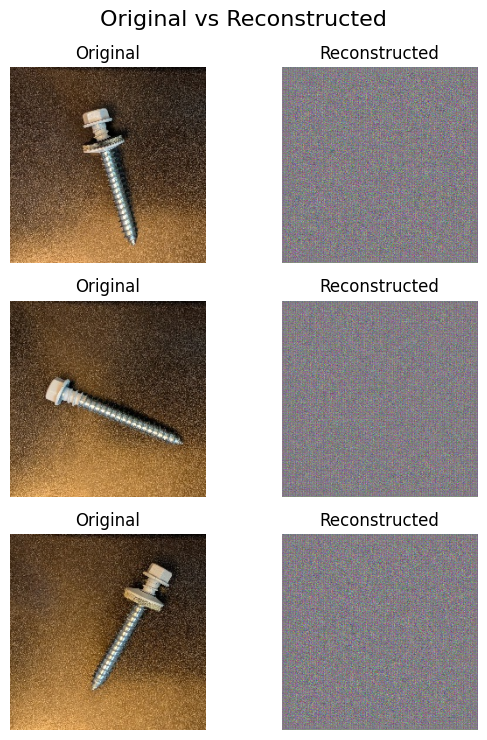

pasta analysis
epoch 0 loss 1.2360882759094238
epoch 1 loss 1.0077319145202637
epoch 2 loss 1.053955078125
epoch 3 loss 1.095069408416748
epoch 4 loss 1.0691015720367432
epoch 5 loss 1.0285414457321167
epoch 6 loss 1.0113567113876343
epoch 7 loss 1.0160481929779053
epoch 8 loss 1.0227994918823242
epoch 9 loss 1.0223795175552368
epoch 10 loss 1.0132189989089966
epoch 11 loss 1.0045570135116577
epoch 12 loss 0.9995420575141907
epoch 13 loss 0.9971395134925842
epoch 14 loss 0.9966943264007568
epoch 15 loss 0.9973527789115906
epoch 16 loss 0.9953133463859558
epoch 17 loss 0.9937746524810791
epoch 18 loss 0.9911056160926819
epoch 19 loss 0.9887621998786926
epoch 20 loss 0.9870255589485168
epoch 21 loss 0.9874659180641174
epoch 22 loss 0.9879818558692932
epoch 23 loss 0.9872907996177673
epoch 24 loss 0.9861520528793335
epoch 25 loss 0.9840486645698547
epoch 26 loss 0.9831861853599548
epoch 27 loss 0.9825314283370972
epoch 28 loss 0.9819064140319824
epoch 29 loss 0.9813871383666992
[0 0 0 0 0

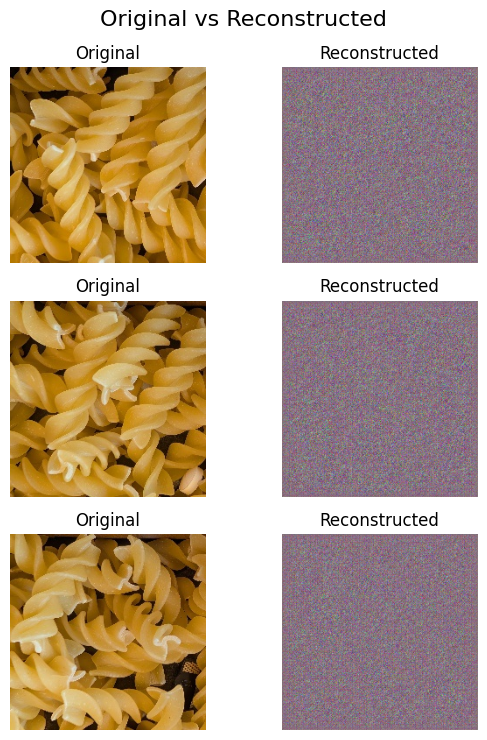

capsule analysis
epoch 0 loss 1.2077252864837646
epoch 1 loss 2.893254041671753
epoch 2 loss 1.2500485181808472
epoch 3 loss 1.4666554927825928
epoch 4 loss 1.8677419424057007
epoch 5 loss 1.6813924312591553
epoch 6 loss 1.3869409561157227
epoch 7 loss 1.3712387084960938
epoch 8 loss 1.4809660911560059
epoch 9 loss 1.4025993347167969
epoch 10 loss 1.177678108215332
epoch 11 loss 1.0525702238082886
epoch 12 loss 1.118577003479004
epoch 13 loss 1.2332549095153809
epoch 14 loss 1.2296254634857178
epoch 15 loss 1.120216727256775
epoch 16 loss 1.0358831882476807
epoch 17 loss 1.0397039651870728
epoch 18 loss 1.093121886253357
epoch 19 loss 1.1207449436187744
epoch 20 loss 1.0916484594345093
epoch 21 loss 1.0438631772994995
epoch 22 loss 1.0204163789749146
epoch 23 loss 1.0274096727371216
epoch 24 loss 1.0356956720352173
epoch 25 loss 1.0296125411987305
epoch 26 loss 1.0170609951019287
epoch 27 loss 1.0106298923492432
epoch 28 loss 1.009026050567627
epoch 29 loss 1.0070395469665527
[0 0 0 0 

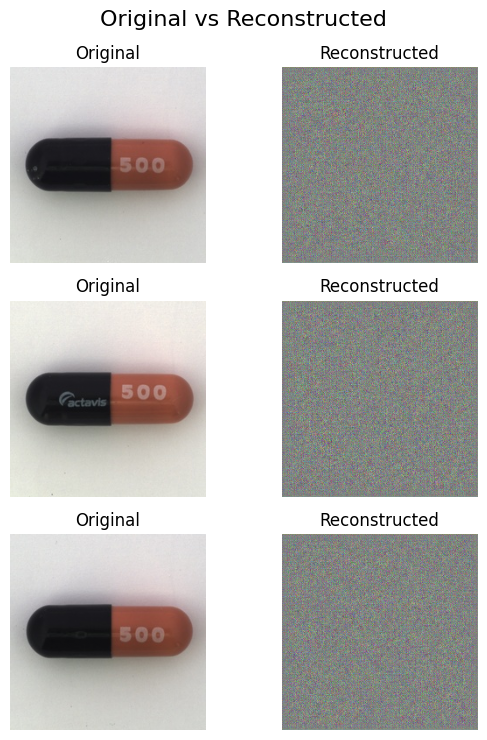

In [ ]:
def do_analysis(class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)

  img_height = training_images.shape[1]
  img_width = training_images.shape[2]

  vae_model = VAE(img_height, img_width)

  train_model(vae_model, training_images, num_epochs=30)

  predictions = predict(vae_model, testing_images)
  basic_evaluation(predictions, testing_labels)
  visualize_reconstructions(vae_model, testing_images, num_images=3)

print("screws analysis")
do_analysis('screws')
print("pasta analysis")
do_analysis('pasta')
print("capsule analysis")
do_analysis('capsule')
